<a href="https://colab.research.google.com/github/elnazshokrollahi/ai-ml-refresh-journey/blob/main/ai-phase-1/ai-phase-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Simulating the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 5000

df = pd.DataFrame ({
    'age':              np.random.randint(18,85,n),
    'gender':           np.random.choice (['M', 'F'], n),
    'lead_time_days':   np.random.randint(1,60, n),
    'prev_no_show':     np.random.choice([0,1,2,3], n, p=[0.6,0.25,0.1,0.05]),
    'reminder_sent':    np.random.choice([0,1], n),
    'distance_miles':   np.random.exponential (10,n).round(1),
    'appt_hour':        np.random.randint(8, 17, n),
    'insurance_type':   np.random.choice(['Medicare','Private','Medicaid','Self-pay'], n)
})

df.head()

,age,gender,lead_time_days,prev_no_show,reminder_sent,distance_miles,appt_hour,insurance_type
0,69,F,11,0,0,22.7,16,Self-pay
1,32,M,45,1,1,1.6,8,Private
2,78,M,26,0,0,2.6,16,Self-pay
3,38,F,22,0,1,1.1,11,Medicaid
4,41,M,28,0,1,1.5,10,Private


In [ ]:
no_show_prob = (
    0.05
    + 0.003 * df['lead_time_days']
    + 0.08  * df['prev_no_show']
    - 0.06  * df['reminder_sent']
    + 0.003 * df['distance_miles']
    - 0.001 * df['age']
)
no_show_prob = no_show_prob.clip(0.05, 0.85)
df['no_show'] = np.random.binomial(1, no_show_prob)

print(df.head())

print(f"\nNo-show rate: {df['no_show'].mean():.1%}")
print(f"\nClass distribution:\n{df['no_show'].value_counts()}")

   age gender  lead_time_days  prev_no_show  reminder_sent  distance_miles  \
0   69      F              11             0              0            22.7   
1   32      M              45             1              1             1.6   
2   78      M              26             0              0             2.6   
3   38      F              22             0              1             1.1   
4   41      M              28             0              1             1.5   

   appt_hour insurance_type  no_show  
0         16       Self-pay        0  
1          8        Private        0  
2         16       Self-pay        0  
3         11       Medicaid        0  
4         10        Private        0  

No-show rate: 14.5%

Class distribution:
no_show
0    4277
1     723
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

In [ ]:
print("=== BASIC INFO ===")
print(df.info())

print("\n=== SUMMARY STATISTICS ===")
print(df.describe())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== TARGET DISTRIBUTION ===")
print(df['no_show'].value_counts())
print(df['no_show'].value_counts(normalize=True).round(3))

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   int64  
 1   gender          5000 non-null   object 
 2   lead_time_days  5000 non-null   int64  
 3   prev_no_show    5000 non-null   int64  
 4   reminder_sent   5000 non-null   int64  
 5   distance_miles  5000 non-null   float64
 6   appt_hour       5000 non-null   int64  
 7   insurance_type  5000 non-null   object 
 8   no_show         5000 non-null   int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 351.7+ KB
None

=== SUMMARY STATISTICS ===
               age  lead_time_days  prev_no_show  reminder_sent  \
count  5000.000000     5000.000000   5000.000000    5000.000000   
mean     51.014600       29.849200      0.610200       0.509800   
std      19.310613       17.081944      0.875676       0.499954   
min      18.000

# EDA Analysis
# Univariate Analysis

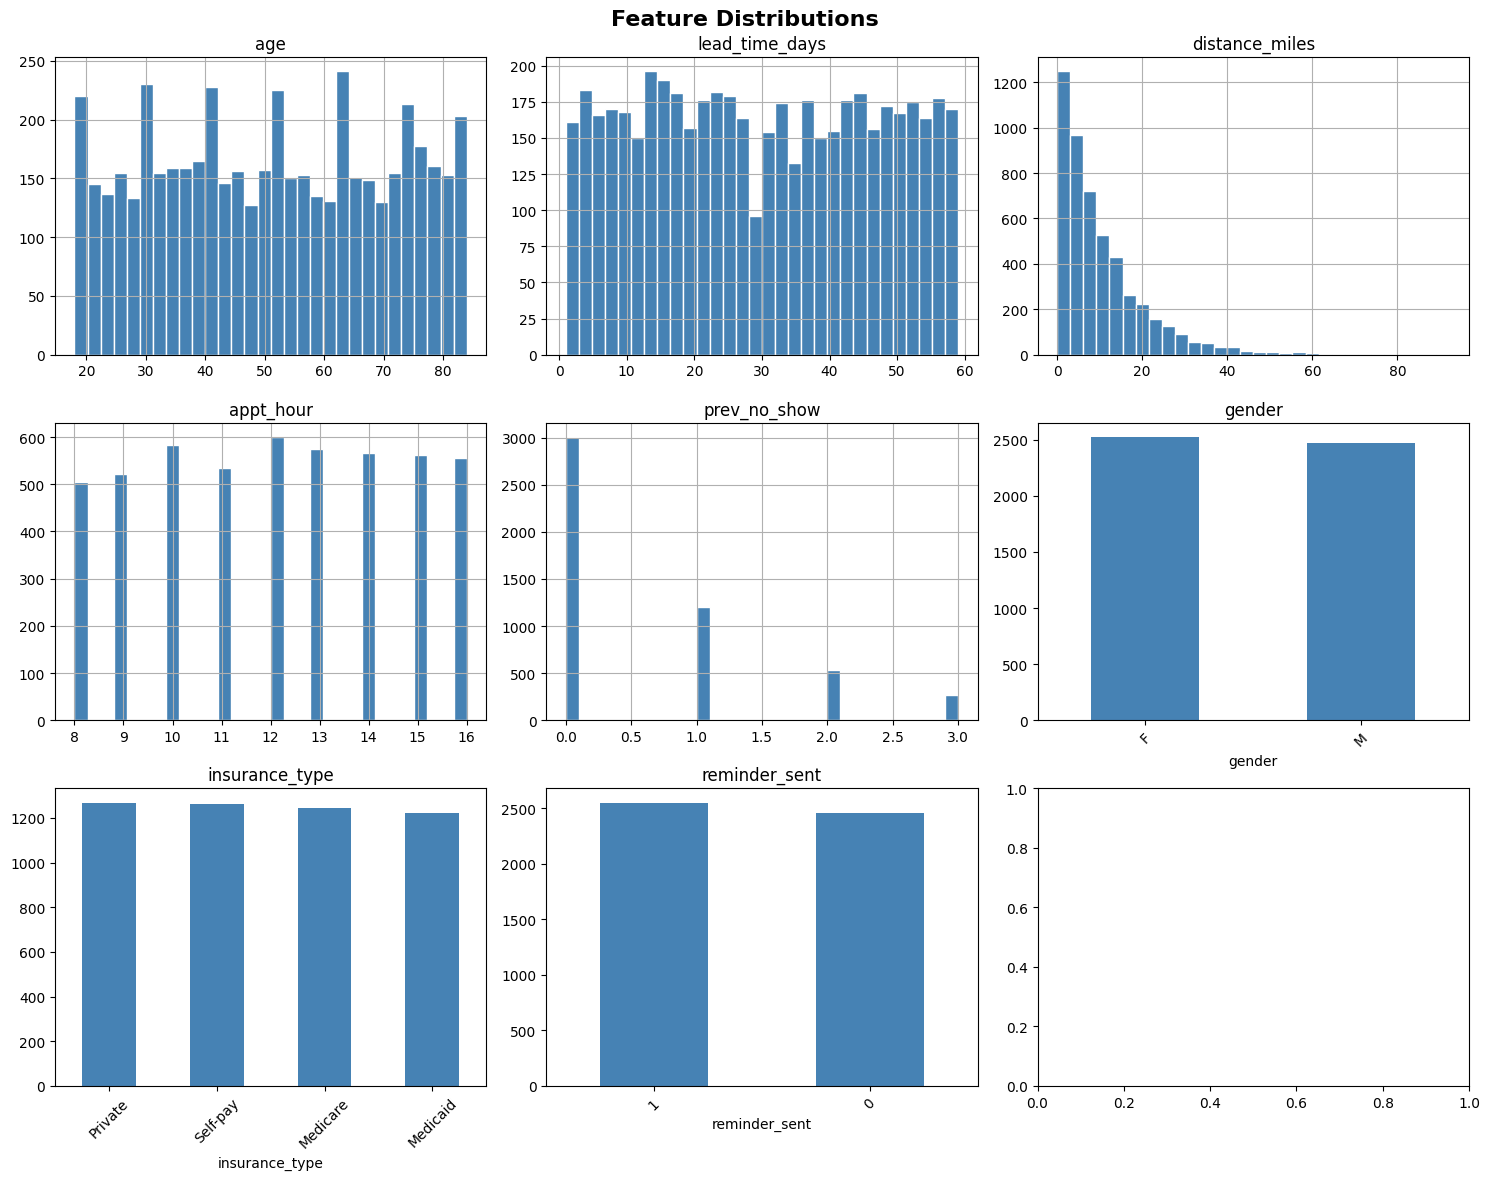

=== NUMERICAL FEATURE STATS ===
           age  lead_time_days  distance_miles  appt_hour  prev_no_show
count  5000.00         5000.00         5000.00    5000.00       5000.00
mean     51.01           29.85           10.39      12.07          0.61
std      19.31           17.08           10.38       2.54          0.88
min      18.00            1.00            0.00       8.00          0.00
25%      34.00           15.00            3.10      10.00          0.00
50%      51.00           29.00            7.20      12.00          0.00
75%      68.00           45.00           14.20      14.00          1.00
max      84.00           59.00           92.20      16.00          3.00


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

numerical = ['age', 'lead_time_days', 'distance_miles',
             'appt_hour', 'prev_no_show']
for i, col in enumerate (numerical):
  ax = axes[i//3][i%3]
  df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor = 'white')
  ax.set_title(col)
  ax.set_xlabel("")

categorical = ['gender', 'insurance_type', 'reminder_sent']
for i, col in enumerate(categorical):
    ax = axes[(i+5)//3][(i+5)%3]
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


print("=== NUMERICAL FEATURE STATS ===")
print(df[numerical].describe().round(2))

# BiVariate Analysis


/tmp/ipykernel_824/1464235886.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  no_show_by_age = df.groupby('age_bin')['no_show'].mean()
/tmp/ipykernel_824/1464235886.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  no_show_by_lead = df.groupby('lead_bin')['no_show'].mean()


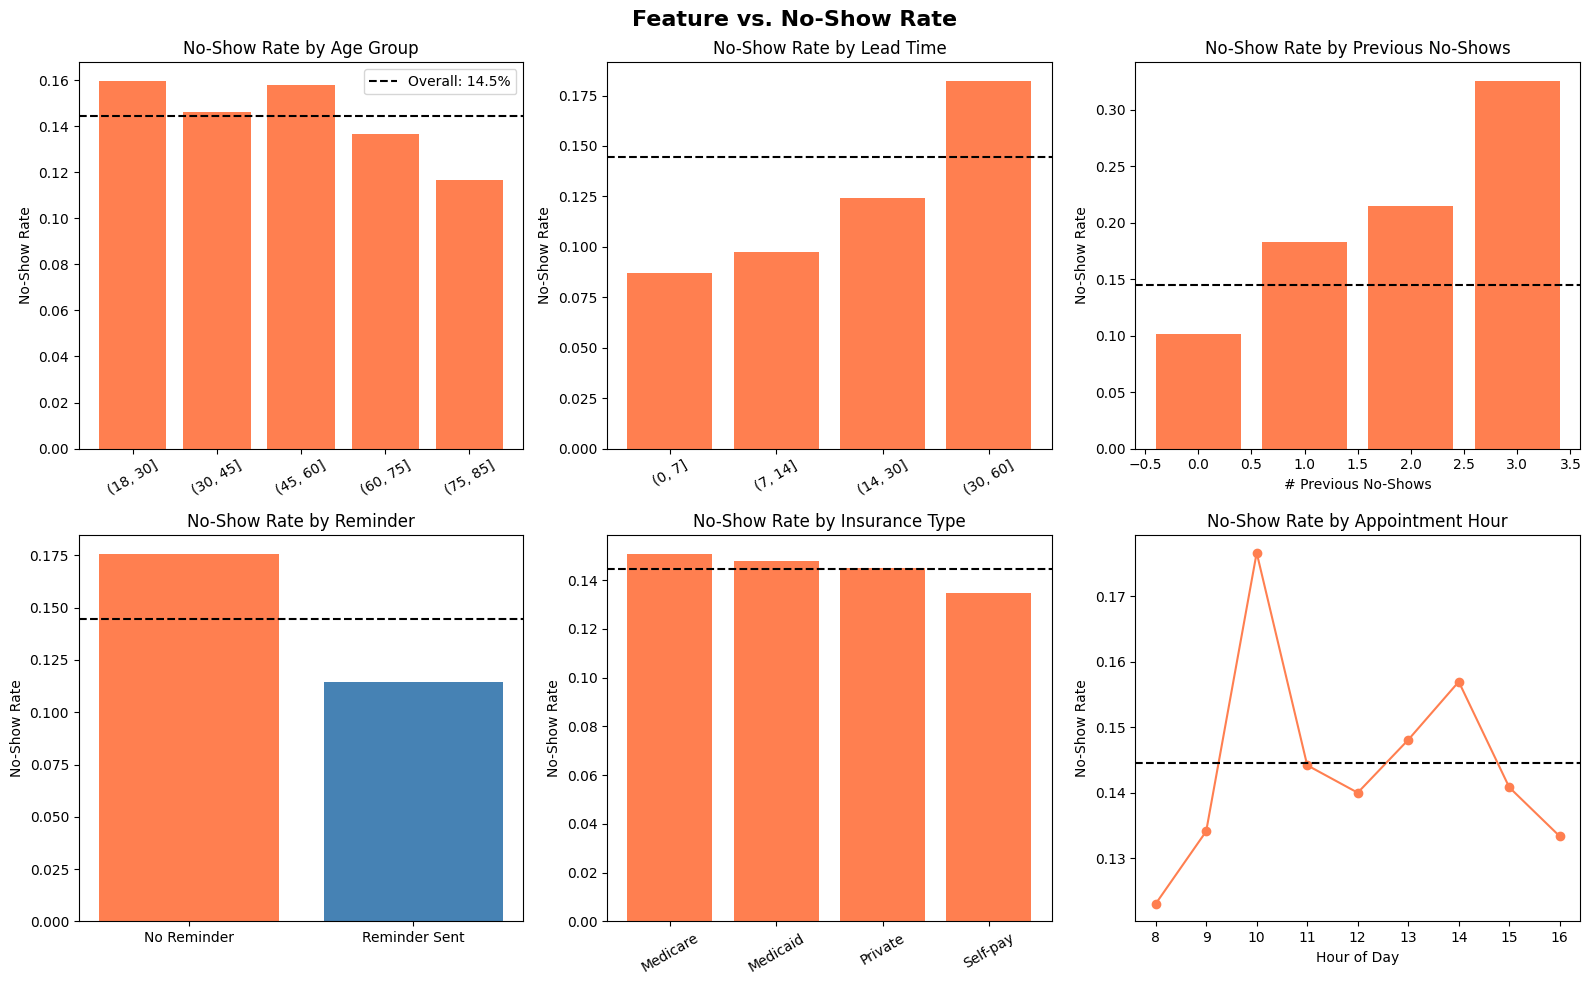

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature vs. No-Show Rate', fontsize=16, fontweight='bold')

df['age_bin'] =pd.cut(df['age'], bins=[18, 30, 45, 60, 75, 85])
no_show_by_age = df.groupby('age_bin')['no_show'].mean()
axes[0,0].bar(range(len(no_show_by_age)), no_show_by_age.values, color='coral')
axes[0,0].set_xticks(range(len(no_show_by_age)))
axes[0,0].set_xticklabels([str(x) for x in no_show_by_age.index], rotation=30)
axes[0,0].set_title('No-Show Rate by Age Group')
axes[0,0].set_ylabel('No-Show Rate')
axes[0,0].axhline(df['no_show'].mean(), color='black', linestyle='--',
                   label=f'Overall: {df["no_show"].mean():.1%}')
axes[0,0].legend()


df['lead_bin'] = pd.cut(df['lead_time_days'], bins=[0,7,14,30,60])
no_show_by_lead = df.groupby('lead_bin')['no_show'].mean()
axes[0,1].bar(range(len(no_show_by_lead)), no_show_by_lead.values, color='coral')
axes[0,1].set_xticks(range(len(no_show_by_lead)))
axes[0,1].set_xticklabels([str(x) for x in no_show_by_lead.index], rotation=30)
axes[0,1].set_title('No-Show Rate by Lead Time')
axes[0,1].set_ylabel('No-Show Rate')
axes[0,1].axhline(df['no_show'].mean(), color='black', linestyle='--')

# Previous no-shows vs no-show rate
no_show_by_prev = df.groupby('prev_no_show')['no_show'].mean()
#print(no_show_by_prev)
axes[0,2].bar(no_show_by_prev.index, no_show_by_prev.values, color='coral')
axes[0,2].set_title('No-Show Rate by Previous No-Shows')
axes[0,2].set_ylabel('No-Show Rate')
axes[0,2].set_xlabel('# Previous No-Shows')
axes[0,2].axhline(df['no_show'].mean(), color='black', linestyle='--')

# Reminder sent vs no-show
no_show_by_reminder = df.groupby('reminder_sent')['no_show'].mean()
axes[1,0].bar(['No Reminder', 'Reminder Sent'], no_show_by_reminder.values,
               color=['coral', 'steelblue'])
axes[1,0].set_title('No-Show Rate by Reminder')
axes[1,0].set_ylabel('No-Show Rate')
axes[1,0].axhline(df['no_show'].mean(), color='black', linestyle='--')


# Insurance type vs no-show
no_show_by_ins = df.groupby('insurance_type')['no_show'].mean().sort_values(ascending=False)
axes[1,1].bar(no_show_by_ins.index, no_show_by_ins.values, color='coral')
axes[1,1].set_title('No-Show Rate by Insurance Type')
axes[1,1].set_ylabel('No-Show Rate')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].axhline(df['no_show'].mean(), color='black', linestyle='--')


# Appointment hour vs no-show
no_show_by_hour = df.groupby('appt_hour')['no_show'].mean()
axes[1,2].plot(no_show_by_hour.index, no_show_by_hour.values,
                marker='o', color='coral')
axes[1,2].set_title('No-Show Rate by Appointment Hour')
axes[1,2].set_ylabel('No-Show Rate')
axes[1,2].set_xlabel('Hour of Day')
axes[1,2].axhline(df['no_show'].mean(), color='black', linestyle='--')

plt.tight_layout()
plt.show()


# MultiVariant Analysis

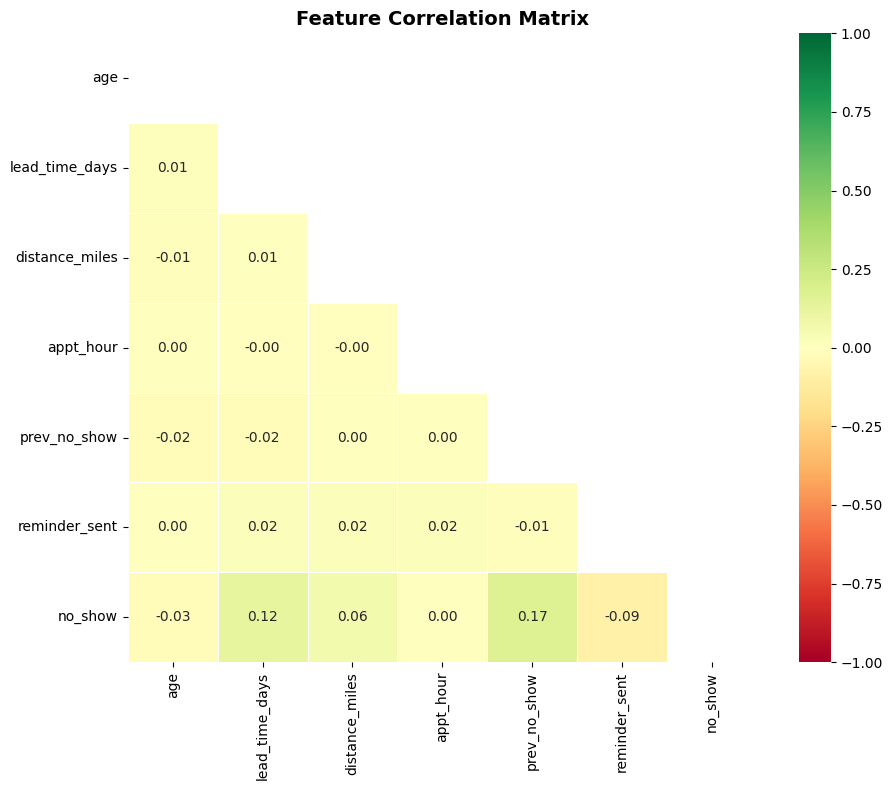

=== CORRELATION WITH TARGET (no_show) ===
prev_no_show      0.171
lead_time_days    0.124
reminder_sent     0.087
distance_miles    0.063
age               0.030
appt_hour         0.002
Name: no_show, dtype: float64

→ Higher absolute value = stronger predictor


In [ ]:
numerical_cols = ['age', 'lead_time_days', 'distance_miles',
                  'appt_hour', 'prev_no_show', 'reminder_sent', 'no_show']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Point biserial correlation with target (for numerical vs binary target)
print("=== CORRELATION WITH TARGET (no_show) ===")
correlations = df[numerical_cols].corr()['no_show'].drop('no_show')
correlations_sorted = correlations.abs().sort_values(ascending=False)
print(correlations_sorted.round(3))
print("\n→ Higher absolute value = stronger predictor")

In [ ]:
#

# Outlier Detection

=== OUTLIER ANALYSIS ===

age:
  Valid range: [-17.0, 119.0]
  Outliers: 0 (0.0%)

lead_time_days:
  Valid range: [-30.0, 90.0]
  Outliers: 0 (0.0%)

distance_miles:
  Valid range: [-13.5, 30.8]
  Outliers: 248 (5.0%)



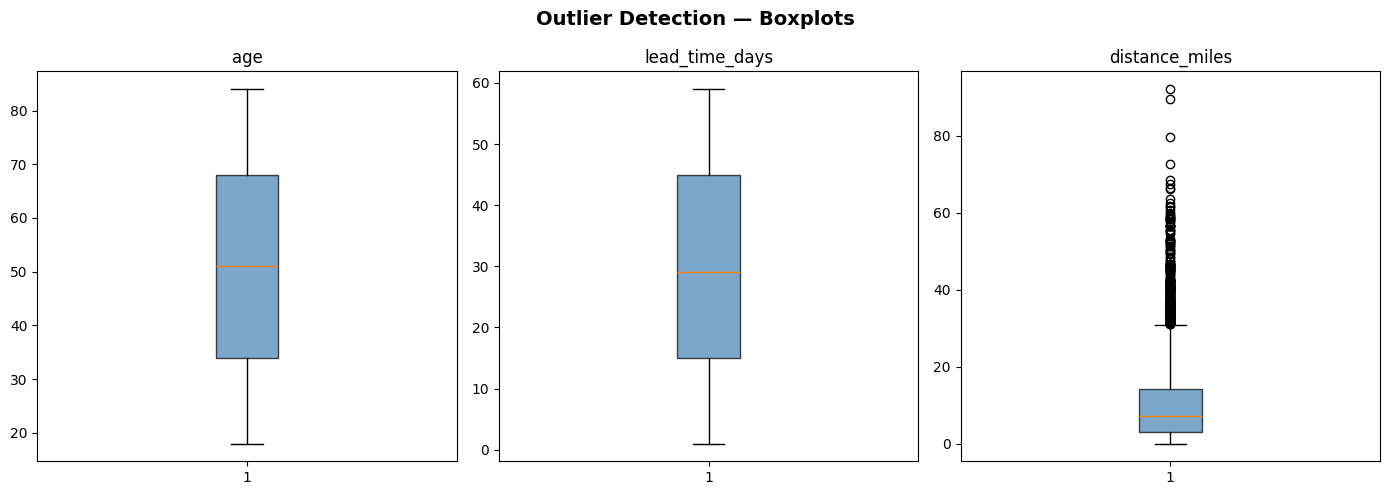

In [ ]:
def detect_outliers_iqr(df, column):
    """IQR method — the standard approach"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers, lower, upper

print("=== OUTLIER ANALYSIS ===\n")
for col in ['age', 'lead_time_days', 'distance_miles']:
    outliers, low, high = detect_outliers_iqr(df, col)
    pct = len(outliers)/len(df)*100
    print(f"{col}:")
    print(f"  Valid range: [{low:.1f}, {high:.1f}]")
    print(f"  Outliers: {len(outliers)} ({pct:.1f}%)\n")

# Visualize with boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Outlier Detection — Boxplots', fontsize=14, fontweight='bold')

for i, col in enumerate(['age', 'lead_time_days', 'distance_miles']):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col)

plt.tight_layout()
plt.show()